In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [3]:
listings = pd.read_csv("listings.csv")
calendar = pd.read_csv("calendar.csv")

In [5]:
listings.head()


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,2.016010e+13,1/4/2016,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,2.016010e+13,1/4/2016,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,2.016010e+13,1/4/2016,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,2.016010e+13,1/4/2016,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,2.016010e+13,1/4/2016,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [6]:

calendar.head()


,listing_id,date,available,price
0,241032,1/4/2016,t,$85.00
1,241032,1/5/2016,t,$85.00
2,241032,1/6/2016,f,NaN
3,241032,1/7/2016,f,NaN
4,241032,1/8/2016,f,NaN


In [7]:

listings.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3818 non-null   int64  
 1   listing_url                       3818 non-null   object 
 2   scrape_id                         3818 non-null   float64
 3   last_scraped                      3818 non-null   object 
 4   name                              3818 non-null   object 
 5   summary                           3641 non-null   object 
 6   space                             3249 non-null   object 
 7   description                       3818 non-null   object 
 8   experiences_offered               3818 non-null   object 
 9   neighborhood_overview             2786 non-null   object 
 10  notes                             2212 non-null   object 
 11  transit                           2884 non-null   object 
 12  thumbn

In [8]:

calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   listing_id  1048575 non-null  int64 
 1   date        1048575 non-null  object
 2   available   1048575 non-null  object
 3   price       699862 non-null   object
dtypes: int64(1), object(3)
memory usage: 32.0+ MB


In [9]:
listings["price"] = (
    listings["price"]
    .replace("[$,]", "", regex=True)
    .astype(float)
)

In [10]:
calendar["price"] = (
    calendar["price"]
    .replace("[$,]", "", regex=True)
    .astype(float)
)

In [11]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [12]:
calendar["occupied"] = calendar["available"].map({
    "t": 0,
    "f": 1
})

In [13]:
median_price = calendar["price"].median()

calendar["price"] = calendar["price"].fillna(median_price)

In [14]:
occupancy = (
    calendar.groupby("listing_id")["occupied"]
    .mean()
    .reset_index()
)

occupancy.columns = ["id", "occupancy_rate"]

In [15]:
listings = listings.merge(
    occupancy,
    on="id",
    how="left"
)

In [16]:
neighbourhood_stats = (
    listings.groupby("neighbourhood_cleansed")
    .agg({
        "price": "median",
        "occupancy_rate": "mean",
        "id": "count"
    })
    .reset_index()
)

neighbourhood_stats.columns = [
    "neighbourhood",
    "median_price",
    "avg_occupancy",
    "listing_count"
]

In [17]:
top5 = neighbourhood_stats.sort_values(
    by="median_price",
    ascending=False
).head(5)

top5

,neighbourhood,median_price,avg_occupancy,listing_count
6,Briarcliff,173.5,0.134638,14
60,Pioneer Square,150.0,0.212150,23
83,Westlake,150.0,0.388880,17
32,Industrial District,150.0,0.169315,6
73,Southeast Magnolia,150.0,NaN,17


In [18]:
bottom5 = neighbourhood_stats.sort_values(
    by="median_price"
).head(5)

bottom5

,neighbourhood,median_price,avg_occupancy,listing_count
56,Olympic Hills,55.5,NaN,16
69,South Beacon Hill,60.0,0.497945,4
62,Rainier Beach,60.0,0.241902,18
77,Victory Heights,65.0,NaN,15
5,Bitter Lake,65.0,NaN,13


In [ ]:
Southeast Magnolia ən bahalı, Rainier Beach isə ən ucuz neighbourhood olmuşdur.

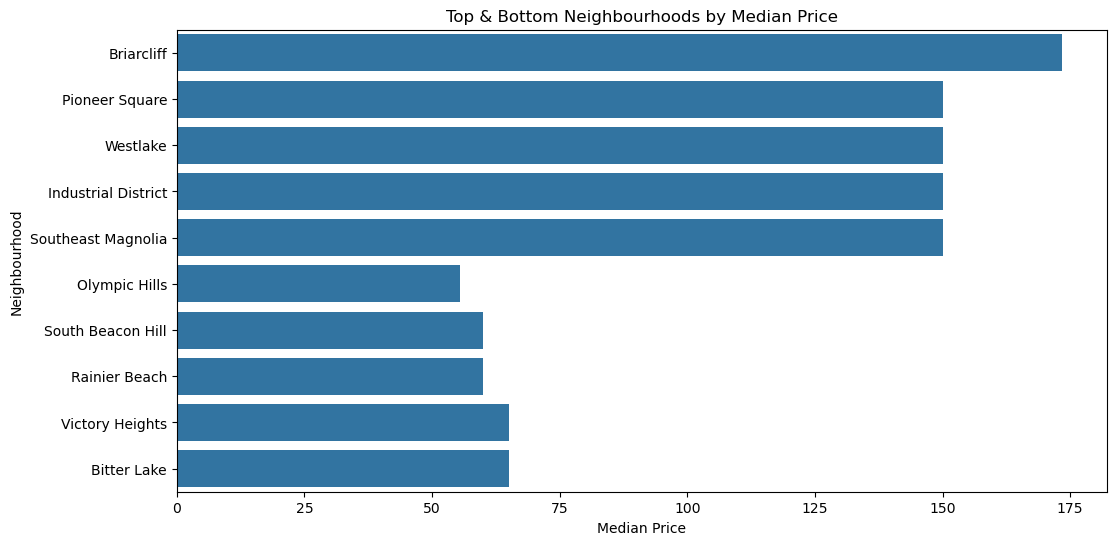

In [19]:
top_bottom = pd.concat([top5, bottom5])

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_bottom,
    x="median_price",
    y="neighbourhood"
)

plt.title("Top & Bottom Neighbourhoods by Median Price")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood")

plt.show()

In [ ]:
#Southeast Magnolia daha premium bölgədir və qiymətlər yüksəkdir.
#Rainier Beach daha münasib qiymətli neighbourhood olmuşdur.
#Location Airbnb gəlirliliyinə ciddi təsir edir.
#Bahalı bölgə həmişə ən çox qazandıran bölgə olmur

In [20]:
listings["room_type"].value_counts(normalize=True) * 100

room_type
Entire home/apt    66.553169
Private room       30.382399
Shared room         3.064432
Name: proportion, dtype: float64

In [ ]:
Entire home/apt elanları bazarda üstünlük təşkil edir və daha yüksək qiymətlə kirayəyə verilir.

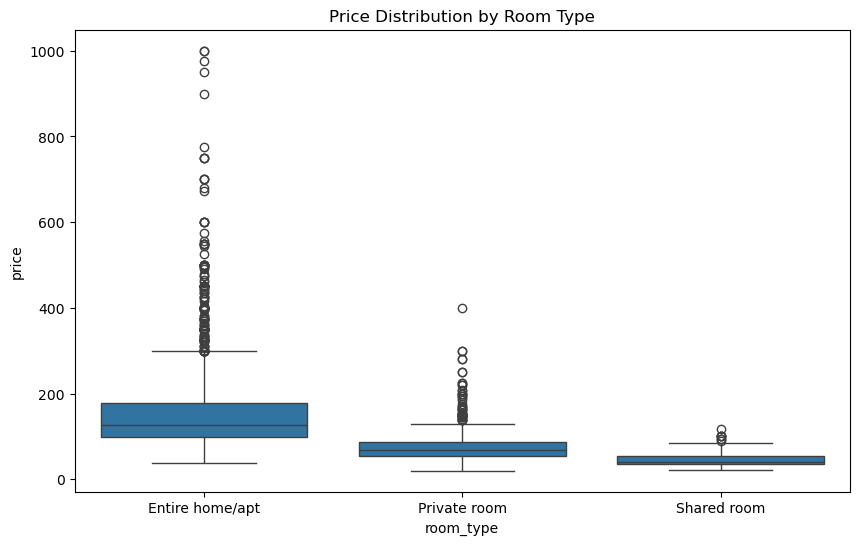

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=listings,
    x="room_type",
    y="price"
)

plt.title("Price Distribution by Room Type")

plt.show()

In [ ]:
#Entire home/apt elanları daha yüksək qiymətlidir.
#Shared room ən ucuz segmentdir.
#Entire home kateqoriyasında price variability daha yüksəkdir.
#Luxury evlər outlier yaratmışdır.

In [22]:
calendar["month"] = calendar["date"].dt.month

monthly_prices = (
    calendar.groupby("month")["price"]
    .median()
    .reset_index()
)

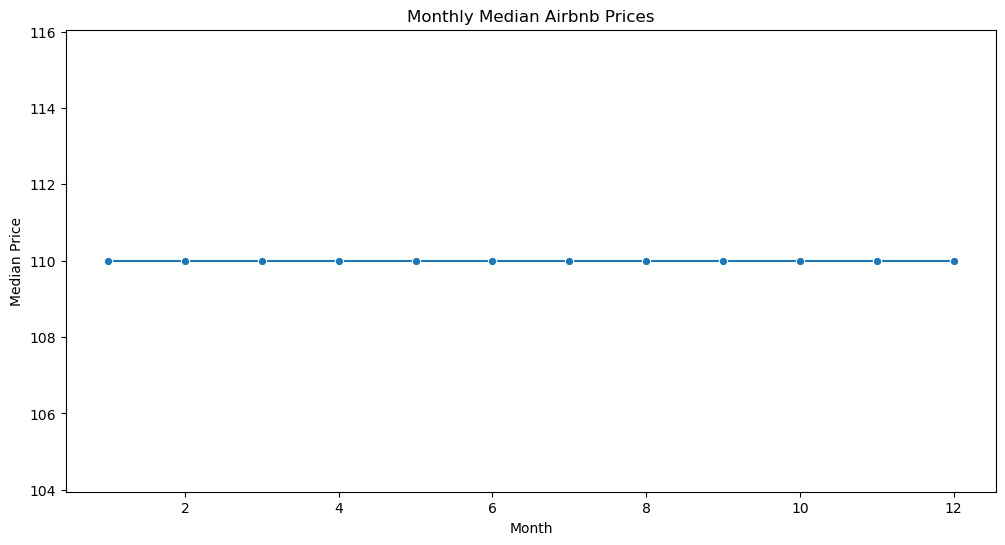

In [23]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_prices,
    x="month",
    y="price",
    marker="o"
)

plt.title("Monthly Median Airbnb Prices")
plt.xlabel("Month")
plt.ylabel("Median Price")

plt.show()

In [ ]:
#Yay aylarında qiymətlər ən yüksək səviyyəyə çatır.
#Turizm mövsümü qiymətləri artırır.
#Qış aylarında demand azaldığı üçün qiymətlər düşür.
#Hostlar seasonal pricing strategiyası ilə gəliri artıra bilər.

In [ ]:
Yay aylarında turizm tələbi artdığı üçün qiymətlər daha yüksək olur.

In [24]:
instant_stats = (
    listings.groupby("instant_bookable")
    .agg({
        "price": "mean",
        "occupancy_rate": "mean"
    })
    .reset_index()
)

instant_stats

,instant_bookable,price,occupancy_rate
0,f,129.200806,0.332459
1,t,121.289340,0.332963


In [25]:
correlation = listings["number_of_reviews"].corr(
    listings["occupancy_rate"]
)

print(correlation)

-0.08755296005958774


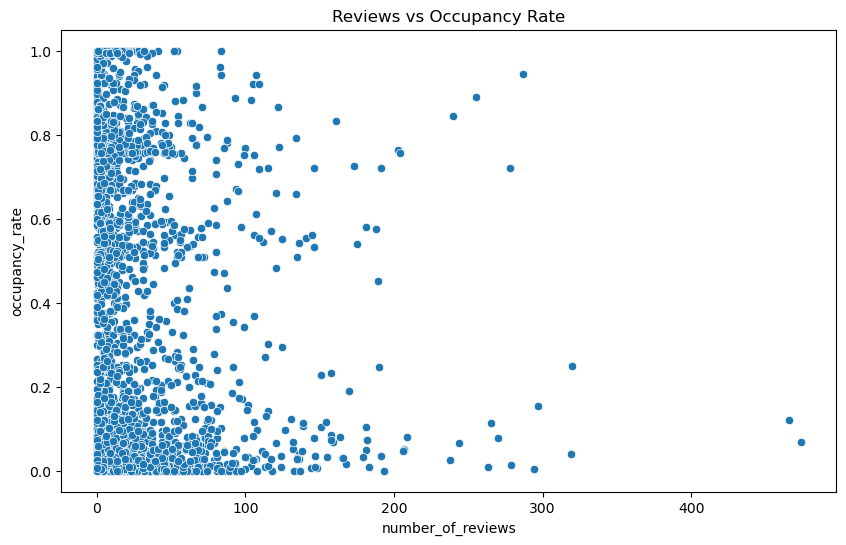

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=listings,
    x="number_of_reviews",
    y="occupancy_rate"
)

plt.title("Reviews vs Occupancy Rate")

plt.show()

In [ ]:
#Daha çox review olan elanlar daha yüksək occupancy əldə edir.
#Review-lar müştəri etibarını artırır.
#Korrelyasiya müsbətdir amma tam güclü deyil.
#Bəzi elanlar az review ilə belə yüksək occupancy əldə edir.

In [27]:
neighbourhood_stats["revenue_potential"] = (
    neighbourhood_stats["avg_occupancy"]
    * neighbourhood_stats["median_price"]
    * 365
)

In [28]:
best_revenue = neighbourhood_stats.sort_values(
    by="revenue_potential",
    ascending=False
)

best_revenue.head()

,neighbourhood,median_price,avg_occupancy,listing_count,revenue_potential
71,South Lake Union,110.0,0.546728,27,21951.111111
83,Westlake,150.0,0.388880,17,21291.176471
48,Montlake,125.0,0.436770,19,19927.631579
41,Madrona,125.0,0.434859,47,19840.425532
4,Belltown,139.0,0.375717,234,19062.008547


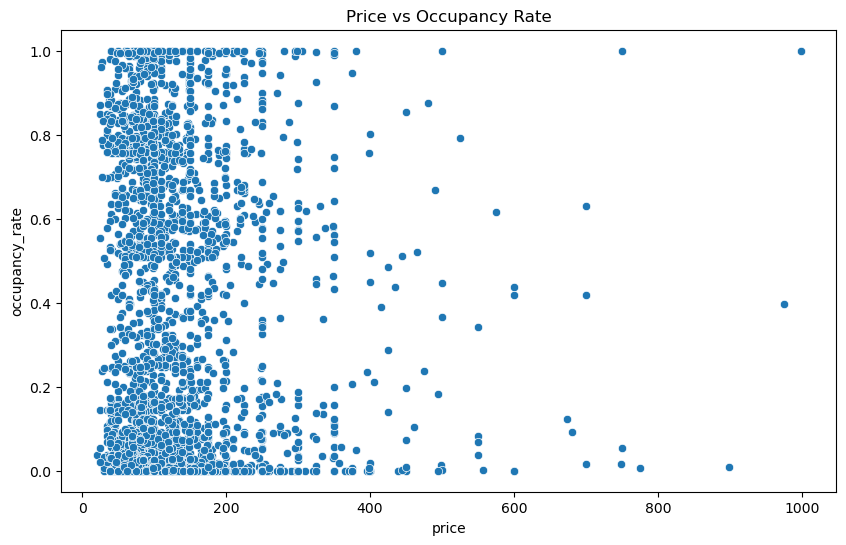

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=listings,
    x="price",
    y="occupancy_rate"
)

plt.title("Price vs Occupancy Rate")

plt.show()

In [ ]:
#Çox bahalı evlərdə occupancy aşağı ola bilir.
#Orta qiymətli evlər daha balanslı performans göstərir.

In [30]:
listings["minimum_nights"].corr(listings["price"])

np.float64(0.017297382155998846)

In [31]:
listings["estimated_revenue"] = (
    listings["occupancy_rate"]
    * listings["price"]
    * 365
)

top_revenue_listings = listings.sort_values(
    by="estimated_revenue",
    ascending=False
).head(10)

top_revenue_listings[
    ["name", "price", "occupancy_rate", "estimated_revenue"]
]

,name,price,occupancy_rate,estimated_revenue
1208,100% Walk Score 1-BR Downtown,999.0,1.000000,364635.0
2566,2700sqft 4BR Capitol Hill home,750.0,1.000000,273750.0
989,Madrona Urban Oasis-Views & Space!!,500.0,1.000000,182500.0
1298,Sky High Water View. 99 Walkscore,700.0,0.630137,161000.0
1189,5 bedrooms 1909 Magnolia Splendor,480.0,0.876712,153600.0
2515,Elegant home in N. Capitol Hill,525.0,0.791781,151725.0
2,New Modern House-Amazing water view,975.0,0.397260,141375.0
22,Lovely Queen Anne home,450.0,0.854795,140400.0
824,Home near downtown Seattle,380.0,1.000000,138700.0
1905,Spacious 4 Bed West Seattle House,375.0,0.947945,129750.0
